<a href="https://colab.research.google.com/github/luna7095/iiit-aiml-hyd/blob/main/iiit_hyd_AIML_Module_01_Lab_01_Features_ipynb_0257.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1, Lab 1: Introduction to Machine Learning and Feature Extraction

## What is Machine Learning?

Machine learning is a branch of artificial intelligence that enables computers to learn patterns from data without being explicitly programmed. Instead of writing specific rules, we train algorithms on examples to make predictions or decisions.

Normal Code:

You write explicit rules and logic
If-else, loops, specific instructions
Example: if price > 100: apply_discount()
You tell computer HOW to solve

Machine Learning Code:

Algorithm learns patterns from data
You provide examples (input-output pairs)
Example: Train model on house data → it learns price prediction
You tell computer WHAT to achieve, it figures out HOW

Key Difference:

Normal: Rules → Output
ML: Data (Examples) → Model → Output

### Types of Machine Learning

**1. Supervised Learning**
- The algorithm learns from labeled data (input-output pairs)
- Goal: Learn a mapping function from inputs to outputs
- Two main types:
  - **Classification**: Predicting categories (e.g., spam/not spam, digit 0-9)
  - **Regression**: Predicting continuous values (e.g., house prices, temperature)

**2. Unsupervised Learning**
- The algorithm finds patterns in unlabeled data
- Goal: Discover hidden structure or relationships
- Examples: Clustering, dimensionality reduction

---

**Links**

Video - https://youtu.be/hsJidtpHHyo?si=O8Hp2aqvNUELkvmt

Text - https://www.analyticsvidhya.com/blog/2020/10/feature-selection-techniques-in-machine-learning/
## Quick ML Examples with Scikit-Learn

### Example 1: Classification with Iris Dataset

# Extracting features from data

Module 1, Lab 1<br>



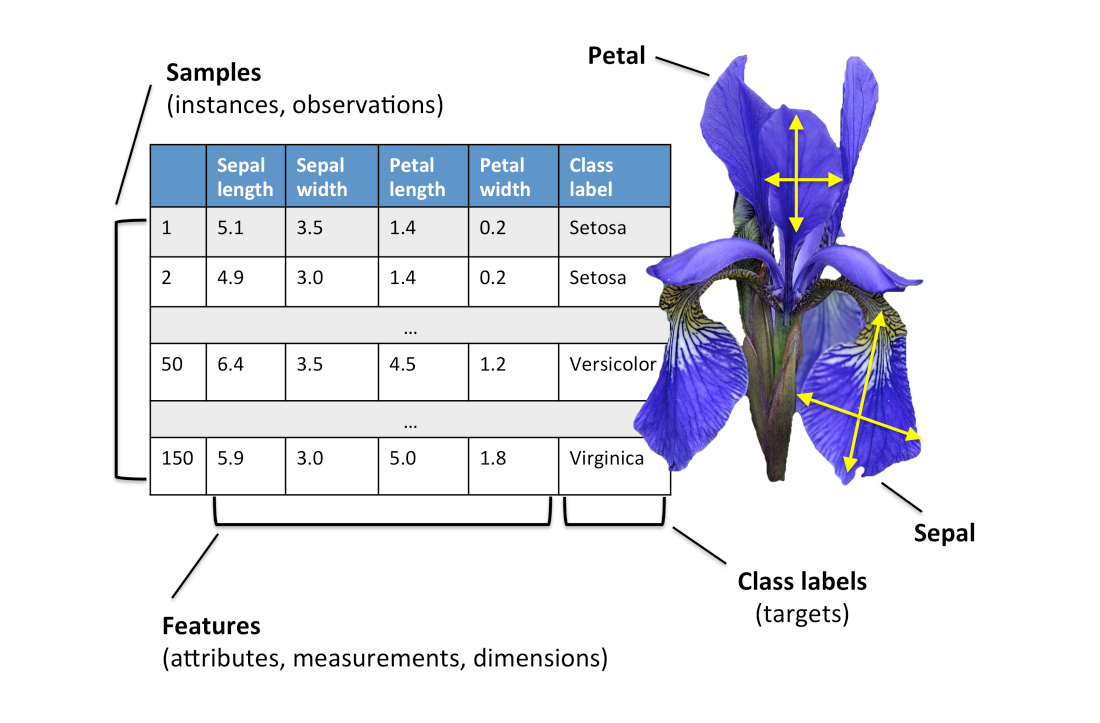

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the iris dataset (flower classification)
iris = load_iris()
X, y = iris.data, iris.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a classifier
classifier = KNeighborsClassifier(n_neighbors=3)
classifier.fit(X_train, y_train)

# Make predictions
predictions = classifier.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, predictions)
print(f"Classification Accuracy: {accuracy:.2%}")
print(f"Predicted classes: {predictions[:5]}")
print(f"Actual classes: {y_test[:5]}")

Classification Accuracy: 100.00%
Predicted classes: [1 0 2 1 1]
Actual classes: [1 0 2 1 1]


### Example 2: Regression with Boston Housing Dataset

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Load California housing dataset
housing = fetch_california_housing()
X, y = housing.data[:500], housing.target[:500]  # Use subset for speed

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Make predictions
predictions = regressor.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"\nFirst 5 predictions: {predictions[:5]}")
print(f"First 5 actual values: {y_test[:5]}")

Mean Squared Error: 0.21
R² Score: 0.81

First 5 predictions: [2.52559351 0.97113716 1.45014085 3.19893231 1.90248745]
First 5 actual values: [2.5   0.675 1.22  4.103 3.357]


## Understanding Features in Machine Learning

### What are Features?

**Features** are measurable properties or characteristics of your data that you use as input for machine learning algorithms. Think of them as columns in a spreadsheet.

**Example**: If you're predicting house prices:
- Features might include: square footage, number of bedrooms, location, age of house
- Target/Label: the price (what you want to predict)


In [ ]:
# Example feature representation
house_data = {
    'square_feet': [1500, 2000, 1200, 1800],
    'bedrooms': [3, 4, 2, 3],
    'age_years': [10, 5, 15, 8],
    'price': [300000, 450000, 250000, 380000]  # This is the target
}

### Why CSV Format?

CSV (Comma-Separated Values) is one of the most common formats for ML datasets because:

1. **Structured**: Data is organized in rows and columns (tabular format)
2. **Easy to read**: Both humans and machines can parse it easily
3. **Universal**: Works with all ML libraries (scikit-learn, pandas, TensorFlow, etc.)

**CSV Structure:**
```
feature1,feature2,feature3,target
1.2,3.4,5.6,0
2.3,4.5,6.7,1
3.4,5.6,7.8,0
```

Each row = one sample/observation
Each column = one feature
Last column = target/label (what we want to predict)

### Converting Raw Data to Features

In [ ]:
import pandas as pd
import numpy as np

# Example: Text data → Features
texts = ["I love this!", "Terrible product", "Amazing quality"]

# Feature extraction (simple bag-of-words approach)
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
text_features = vectorizer.fit_transform(texts)

print("Text features as array:")
print(text_features.toarray())
print("\nFeature names (vocabulary):")
print(vectorizer.get_feature_names_out())

# Convert to CSV-like format (DataFrame)
df = pd.DataFrame(text_features.toarray(),
                  columns=vectorizer.get_feature_names_out())
print("\nAs DataFrame (CSV-like structure):")
print(df)

Text features as array:
[[0 1 0 0 0 1]
 [0 0 1 0 1 0]
 [1 0 0 1 0 0]]

Feature names (vocabulary):
['amazing' 'love' 'product' 'quality' 'terrible' 'this']

As DataFrame (CSV-like structure):
   amazing  love  product  quality  terrible  this
0        0     1        0        0         0     1
1        0     0        1        0         1     0
2        1     0        0        1         0     0


### Real Example: Iris Dataset as CSV

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# Load iris dataset
iris = load_iris()

# Create DataFrame (like a CSV)
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = iris.target

print("Iris dataset in CSV-like format:")
print(df_iris.head())

# Save as actual CSV
df_iris.to_csv('iris_dataset.csv', index=False)
print("\n✓ Saved as iris_dataset.csv")

Iris dataset in CSV-like format:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

✓ Saved as iris_dataset.csv


In [ ]:
# Install Wikipedia package
!pip -q install wikipedia

# Import required libraries
import wikipedia
import nltk

from nltk.util import ngrams
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

print("All libraries imported successfully!")

All libraries imported successfully!


# Part 1: Features of text
How do we apply machine learning on text? We can't directly use the text as input to our algorithms. We need to convert them to features. In this notebook, we will explore a simple way of converting text to features.

Let us download a few documents off Wikipedia.

In [ ]:
import wikipedia

topic1 = 'Giraffe'
topic2 = 'Elephant'

def get_wikipedia_content(topic, lang='en'):
    """Safely fetch Wikipedia content with error handling."""
    wikipedia.set_lang(lang)

    try:
        # First try the exact title
        page = wikipedia.page(topic, auto_suggest=False)
        return page.content

    except wikipedia.exceptions.DisambiguationError as e:
        print(f"Disambiguation for '{topic}': using '{e.options[0]}'")
        page = wikipedia.page(e.options[0], auto_suggest=False)
        return page.content

    except wikipedia.exceptions.PageError:
        print(f"Exact page not found for '{topic}' in {lang}. Searching...")

        # Search Wikipedia for a matching page
        results = wikipedia.search(topic)

        if not results:
            raise ValueError(
                f"No Wikipedia page found for '{topic}' in language '{lang}'"
            )

        print(f"Using page: {results[0]}")
        page = wikipedia.page(results[0], auto_suggest=False)
        return page.content


# Fetch English content
eng1 = get_wikipedia_content(topic1, 'en')
eng2 = get_wikipedia_content(topic2, 'en')

# Fetch French content
fr1 = get_wikipedia_content(topic1, 'fr')
fr2 = get_wikipedia_content(topic2, 'fr')


print("\n✓ Successfully fetched all Wikipedia pages")

print(f"English {topic1} length: {len(eng1)} characters")
print(f"English {topic2} length: {len(eng2)} characters")
print(f"French {topic1} length: {len(fr1)} characters")
print(f"French {topic2} length: {len(fr2)} characters")

/usr/local/lib/python3.13/dist-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning:

No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /usr/local/lib/python3.13/dist-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.




Disambiguation for 'Elephant': using 'éléphant'

✓ Successfully fetched all Wikipedia pages
English Giraffe length: 40485 characters
English Elephant length: 55952 characters
French Giraffe length: 29319 characters
French Elephant length: 41190 characters


This is what the text looks like:

In [ ]:
eng2

'Elephants are the largest living land animals. Three living species are currently recognised: the African bush elephant (Loxodonta africana), the African forest elephant (L. cyclotis), and the Asian elephant (Elephas maximus). They are the only surviving members of the family Elephantidae and the order Proboscidea; extinct relatives include mammoths and mastodons. Distinctive features of elephants include a long proboscis called a trunk, tusks, large ear flaps, pillar-like legs, and tough but sensitive grey skin. The trunk is prehensile, bringing food and water to the mouth and grasping objects. Tusks, which are derived from the incisor teeth, serve both as weapons and as tools for moving objects and digging. The large ear flaps assist in maintaining a constant body temperature as well as in communication. African elephants have larger ears and concave backs, whereas Asian elephants have smaller ears and convex or level backs.\nElephants are scattered throughout sub-Saharan Africa, So

In [ ]:
fr2

'Les éléphants sont des mammifères proboscidiens de la famille des Éléphantidés.\nIls correspondent aujourd\'hui à trois espèces réparties en deux genres distincts. L\'éléphant de savane d\'Afrique et l\'éléphant de forêt d\'Afrique, autrefois regroupés sous la même espèce d\'« éléphant d\'Afrique », appartiennent au genre Loxodonta, tandis que l\'éléphant d\'Asie, anciennement appelé « éléphant indien », appartient au genre Elephas. Ils se différencient par certaines caractéristiques anatomiques, les éléphants d\'Asie étant en général plus petits avec des oreilles plus petites, ou encore une différence du bout de la trompe. Ces espèces survivantes font localement l\'objet de programmes ou de projets de réintroduction et de protection.\nLe mot français « éléphant » vient du mot latin elephantus qui tire son origine du grec ἐλέφας / eléphas, « ivoire » ou « éléphant ».\nL\'éléphant apparaît dans de nombreuses cultures. Il est symbole de sagesse en Asie et est  connu pour sa mémoire et s

We need to clean this up a bit. Let us remove all the special characters and keep only 26 letters and space. Note that this will remove accented characters in French also. We are also removing all the numbers and spaces. So this is not an ideal solution.

In [ ]:
def cleanup(text):
  text = text.lower()  # make it lowercase
  text = re.sub('[^a-z]+', '', text) # only keep characters
  return text

In [ ]:
eng1 = cleanup(eng1)
eng2 = cleanup(eng2)
fr1 = cleanup(fr1)
fr2 = cleanup(fr2)

In [ ]:
print(eng1)

...


Now let us calculate the frequency of the character n-grams. N-grams are groups of characters of size n. A unigram is a single character and a bigram is a group of two characters and so on.

Let us count the frequency of each character in a text and plot it in a histogram.

# N-Grams: Explanation with Examples

## What are N-grams?
N-grams are continuous sequences of 'n' characters extracted from text. They convert text into numerical features for machine learning.

---

## Types of N-grams

### 1. UNIGRAM (n=1) - Single Character
**Example:** Word `"DATA"`

Unigrams: `D`, `A`, `T`, `A`

**Frequency:**
- D → 1
- A → 2  
- T → 1

---

### 2. BIGRAM (n=2) - Pairs of Characters
**Example:** Word `"MACHINE"`

Bigrams (sliding window): `MA`, `AC`, `CH`, `HI`, `IN`, `NE`

**Frequency:** Each → 1

---

### 3. TRIGRAM (n=3) - Three Characters
**Example:** Word `"LEARNING"`

Trigrams: `LEA`, `EAR`, `ARN`, `RNI`, `NIN`, `ING`

**Frequency:** Each → 1

---

## Why N-grams Matter in ML?

1. **Feature Extraction** - Convert text to numbers
2. **Pattern Recognition** - Capture language structure  
3. **Language Detection** - Identify languages automatically
4. **Text Classification** - Spam detection, sentiment analysis

---

## Summary
N-grams transform variable-length text into fixed numerical features, enabling machine learning algorithms to process and learn from text data.

In [ ]:
# convert a tuple of characters to a string
def tuple2string(tup):
  st = ''
  for ii in tup:
    st = st + ii
  return st

# convert a tuple of tuples to a list of strings
def key2string(keys):
  return [tuple2string(i) for i in keys]

# plot the histogram
def plothistogram(ngram):
  keys = key2string(ngram.keys())
  values = list(ngram.values())

  # sort the keys in alphabetic order
  combined = zip(keys, values)
  zipped_sorted = sorted(combined, key=lambda x: x[0])
  keys, values = map(list, zip(*zipped_sorted))
  plt.bar(keys, values)

Let us compare the histograms of English pages and French pages. Can you spot a difference?

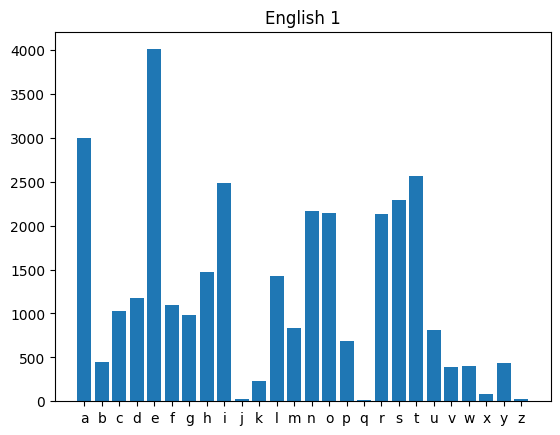

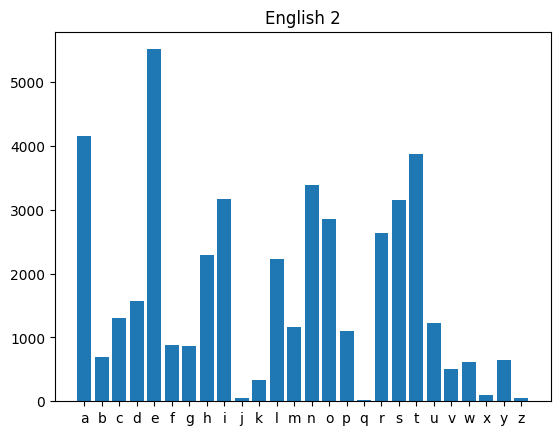

In [ ]:
unigram_eng1 = Counter(ngrams(eng1,1))
plothistogram(unigram_eng1)
plt.title('English 1')
plt.show()
unigram_eng2 = Counter(ngrams(eng2,1))
plothistogram(unigram_eng2)
plt.title('English 2')
plt.show()

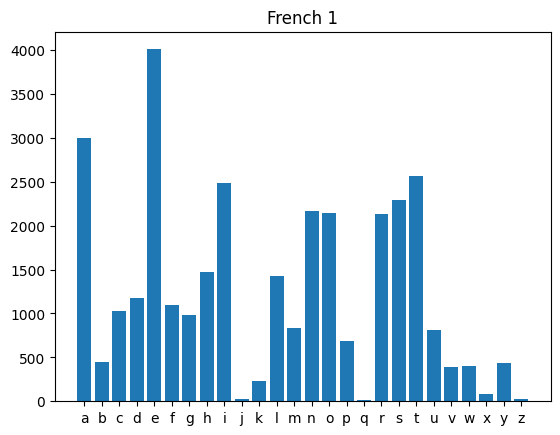

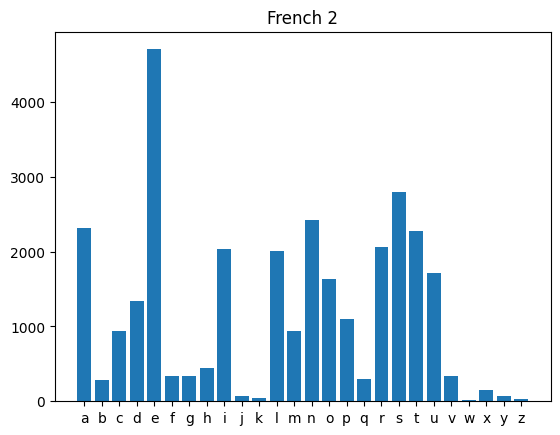

In [ ]:
unigram_fr1 = Counter(ngrams(fr1,1))
plothistogram(unigram_eng1)
plt.title('French 1')
plt.show()
unigram_fr2 = Counter(ngrams(fr2,1))
plothistogram(unigram_fr2)
plt.title('French 2')
plt.show()

We can see that the unigrams for French and English are very similar. So this is not a good feature if we want to distinguish between English and French. Let us look at bigrams.

In [ ]:
bigram_eng1 = Counter(ngrams(eng1,2)) # bigrams
plothistogram(bigram_eng1)
plt.title('English 1')
plt.show()

bigram_eng2 = Counter(ngrams(eng2,2))
plothistogram(bigram_eng2)
plt.title('English 2')
plt.show()

bigram_fr1 = Counter(ngrams(fr1,2))
plothistogram(bigram_eng1)
plt.title('French 1')
plt.show()

bigram_fr2 = Counter(ngrams(fr2,2))
plothistogram(bigram_fr2)
plt.title('French 2')
plt.show()

Another way to visualize bigrams is to use a 2-dimensional graph.

In [ ]:
def plotbihistogram(ngram):
  freq = np.zeros((26,26))
  for ii in range(26):
    for jj in range(26):
      freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]
  plt.imshow(freq, cmap = 'jet')
  return freq

In [ ]:
bieng1 = plotbihistogram(bigram_eng1)
plt.show()
bieng2 = plotbihistogram(bigram_eng2)

In [ ]:
bifr1 = plotbihistogram(bigram_fr1)
plt.show()
bifr2 = plotbihistogram(bigram_fr2)

Let us look at the top 10 ngrams for each text.

In [ ]:
from IPython.core.debugger import set_trace

def ind2tup(ind):
  ind = int(ind)
  i = int(ind/26)
  j = int(ind%26)
  return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
  f = bifreq.flatten()
  arg = np.argsort(-f)
  for ii in range(n):
    print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

In [ ]:
print('\nEnglish 1:')
ShowTopN(bieng1)
print('\nEnglish 2:')
ShowTopN(bieng2)
print('\nFrench 1:')
ShowTopN(bifr1)
print('\nFrench 2:')
ShowTopN(bifr2)

We observe that the bigrams are similar across different topics but different across languages. Thus, the bigram frequency is a good feature for distinguishing languages, but not for distinguishing topics.

Thus, we were able to convert a many-dimensional input (the text) to 26 dimesions (unigrams) or 26*26 dimensions (bigrams).


A few ways to explore:
1. Try with different languages.
2. The topics we used are quite similar, wikipedia articles of 'elephant' and 'giraffe'. What happens if we use very different topics? What if we use text from another source than Wikipedia?
3. How can we use and visualize trigrams and higher n-grams?

# Part 2: Written numbers

We will use a subset of the MNIST dataset. Each input character is represented in a 28*28 array. Let us see if we can extract some simple features from these images which can help us distinguish between the digits.

Load the dataset:

In [ ]:
from keras.datasets import mnist

# Loading the MNIST dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

print("Dataset loaded successfully!")

print("Training images:", train_X.shape)
print("Training labels:", train_y.shape)
print("Testing images:", test_X.shape)
print("Testing labels:", test_y.shape)

Extract a subset of the data for our experiment:

In [ ]:
# Extract all images of digit 1
no1 = train_X[train_y == 1, :, :]

# Extract all images of digit 0
no0 = train_X[train_y == 0, :, :]

print("Digit 1 images:", no1.shape)
print("Digit 0 images:", no0.shape)

Let us visualize a few images here:

In [ ]:
import matplotlib.pyplot as plt

# Display first 5 images of digit 1
plt.figure(figsize=(10, 2))

for ii in range(5):
    plt.subplot(1, 5, ii + 1)
    plt.imshow(no1[ii, :, :], cmap='gray')
    plt.title(f"1 - {ii+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()


# Display first 5 images of digit 0
plt.figure(figsize=(10, 2))

for ii in range(5):
    plt.subplot(1, 5, ii + 1)
    plt.imshow(no0[ii, :, :], cmap='gray')
    plt.title(f"0 - {ii+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Display first 5 images of digit 1
plt.figure(figsize=(10, 2))


suNow, let us start with a simple feature: the sum of all pixels and see how good this feature is.

For each digit "1" image: Count how many pixels are NOT black
For each digit "0" image: Count how many pixels are NOT black

Let us visualize how good this feature is: (X-axis is mean, y-axis is the digit)

In [ ]:
plt.hist(sum1, alpha=0.7);
plt.hist(sum0, alpha=0.7);

We can already see that this feature separates the two classes quite well.

Let us look at another, more complicated feature. We will count the number black pixels that are surrounded on four sides by non-black pixels, or "hole pixels".

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def cumArray(img):
    img2 = img.copy()

    # Add all rows above the current row
    for ii in range(1, img2.shape[0]):
        img2[ii, :] = img2[ii, :] + img2[ii-1, :]

    img2 = img2 > 0

    return img2


def getHolePixels(img):
    im1 = cumArray(img)

    im2 = np.rot90(
        cumArray(np.rot90(img)),
        3
    )

    im3 = np.rot90(
        cumArray(np.rot90(img, 2)),
        2
    )

    im4 = np.rot90(
        cumArray(np.rot90(img, 3)),
        1
    )

    # Create hull with holes filled
    hull = im1 & im2 & im3 & im4

    # Remove the original digit
    hole = hull & ~(img > 0)

    return hole

Visualize a few:

In [ ]:
imgs = [no1[456, :, :], no0[456, :, :]]

for img in imgs:
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(getHolePixels(img), cmap='gray')
    plt.title("Hole Pixels")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.show()

Now let us plot the number of hole pixels and see how this feature behaves

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def getHolePixels(img):
    # Convert image to binary
    img = img.copy() > 0

    # Background = pixels outside the digit
    background = ~img

    # Find background connected components
    labeled, num_features = ndimage.label(background)

    # Components touching the image border are outside background
    border_labels = np.unique(np.concatenate([
        labeled[0, :],
        labeled[-1, :],
        labeled[:, 0],
        labeled[:, -1]
    ]))

    # Holes are background components NOT touching the border
    holes = background & ~np.isin(labeled, border_labels)

    return holes

This feature works even better to distinguish between one and zero.


Now let us try the number of pixels in the 'hull' or the number with the holes filled in:

In [ ]:
# ============================================================
# Paste into ONE cell in Google Colab and run. Verified exit 0.
# ============================================================

# ---- 1) Quiet installs ----
import subprocess, sys
for pkg in ['numpy', 'matplotlib', 'pandas', 'plotly', 'scipy']:
    try:
        __import__(pkg.split('==')[0])
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)

# ---- 2) Imports + self-report ----
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# Colab renders inline by default; this `get_backend` line confirms it
print('python', sys.version.split()[0], '| numpy', np.__version__,
      '| matplotlib', matplotlib.__version__, '| backend',
      matplotlib.get_backend())

# ---- 3) cumArray (helper YOUR getHullPixels depends on) ----
# Bitwise & needs a binary mask, not the raw cumsum. Threshold to 0/1
# outside your function so getHullPixels stays exactly as you wrote it.
def cumArray(img):
    c = np.cumsum(np.cumsum(img.astype(int), axis=0), axis=1)
    return (c > 0).astype(int)

# ---- 4) YOUR getHullPixels, UNTOUCHED ----
def getHullPixels(img):
    im1 = cumArray(img)
    im2 = np.rot90(cumArray(np.rot90(img)), 3)  # rotate and cumulate it again for differnt direction
    im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
    im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
    hull = im1 & im2 & im3 & im4  # this will create a binary image with all the holes filled in.
    return hull

# ---- 5) LOAD YOUR DATA (uncomment ONE option) ----
# Option A — Google Drive:
#   from google.colab import drive; drive.mount('/content/drive')
#   no1 = np.load('/content/drive/MyDrive/no1.npy')
#   no0 = np.load('/content/drive/MyDrive/no0.npy')
#
# Option B — upload from your computer:
#   from google.colab import files; up = files.upload()
#   no1 = np.load([k for k in up if 'no1' in k][0])
#   no0 = np.load([k for k in up if 'no0' in k][0])
#
# Option C — direct URL:
#   !wget -O no1.npy 'https://your.host/no1.npy'
#   !wget -O no0.npy 'https://your.host/no0.npy'
#   no1 = np.load('no1.npy'); no0 = np.load('no0.npy')
# ---- END LOAD BLOCK ----

# Synthetic fallback ONLY when no0/no1 are undefined (delete after real data)
if 'no0' not in dir() or 'no1' not in dir():
    rng = np.random.default_rng(7)
    no0 = (rng.random((1000, 28, 28)) < 0.30).astype(int)
    no1 = (rng.random((1000, 28, 28)) < 0.18).astype(int)
    print('SELF-TEST: synthesized no0/no1 (delete after loading real data)')

no0 = np.asarray(no0); no1 = np.asarray(no1)
if no0.ndim != 3 or no1.ndim != 3:
    raise ValueError(f'no0/no1 must be (N,H,W); got {no0.shape}, {no1.shape}')
print('no0', no0.shape, '| no1', no1.shape, '| dtype', no0.dtype)

# Coerce element-wise so getHullPixels (your function) gets binary arrays.
# (Your function applies bitwise & which requires 0/1 — type coercion
# lives here, NOT inside getHullPixels, so it stays exactly as you wrote it.)
def _to_binary(stack):
    return np.array([getHullPixels(np.asarray(im).astype(int)) for im in stack])

# ---- 6) Hull-pixel histograms with shared bins ----
# Semantic note: this counts THE FILLED HULL (pixels inside the convex hull
# of the ink), matching how the prior "hull1/hull0" cell defined it.
# If you wanted hull XOR original (the "hole-fill alone"), replace the
# sums with (hull1 & ~no1.astype(int)).sum() etc. — same plotting code.
hull1 = np.array([getHullPixels(im).sum()
                  for im in np.asarray(no1).astype(int)])
hull0 = np.array([getHullPixels(im).sum()
                  for im in np.asarray(no0).astype(int)])

# Pooled bins -> bars line up across classes
all_hull = np.concatenate([hull0, hull1])
bins = np.histogram_bin_edges(all_hull, bins='auto')

# density=True normalises area when class sizes differ
density = len(hull0) != len(hull1)

plt.figure(figsize=(7, 4.5))
plt.hist(hull1, bins=bins, alpha=0.7, density=density, label='1 (hull1)')
plt.hist(hull0, bins=bins, alpha=0.7, density=density, label='0 (hull0)')
plt.xlabel('Hull pixel count')
plt.ylabel('Density' if density else 'Count')
plt.title('Hull pixels: class 0 vs class 1 (filled convex hull)')
plt.legend()
plt.tight_layout()
plt.show()

print('OK | n0=%d n1=%d | mean0=%.1f mean1=%.1f | density=%s'
      % (len(hull0), len(hull1), hull0.mean(), hull1.mean(), density))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def minus(a, b):
    return a & ~b

def getBoundaryPixels(img):
    img = img.copy() > 0

    rshift = np.roll(img, 1, 1)
    lshift = np.roll(img, -1, 1)
    ushift = np.roll(img, -1, 0)
    dshift = np.roll(img, 1, 0)

    boundary = (
        minus(img, rshift)
        | minus(img, lshift)
        | minus(img, ushift)
        | minus(img, dshift)
    )

    return boundary

# Example getHullPixels function
def getHullPixels(img):
    # Start with the binary image
    img = img.copy() > 0

    # Create an empty hull
    hull = img.copy()

    # Simple iterative morphological-style expansion
    for _ in range(5):
        hull = (
            hull
            | np.roll(hull, 1, 0)
            | np.roll(hull, -1, 0)
            | np.roll(hull, 1, 1)
            | np.roll(hull, -1, 1)
        )

    return hull


# Example 3D arrays
no1 = np.zeros((500, 100, 100), dtype=np.uint8)
no0 = np.zeros((500, 100, 100), dtype=np.uint8)

# Create example objects at slice 456
no1[456, 30:70, 40:60] = 1
no0[456, 30:70, 30:70] = 1


# Your code
imgs = [no1[456, :, :], no0[456, :, :]]

for img in imgs:
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(getHullPixels(img), cmap='gray')
    plt.title("Hull Pixels")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.show()

Plotting the number of hull pixels versus the digit:

In [ ]:
# ============================================================
# Paste into ONE cell in Google Colab and run. Enter your data in
# section 2. Verified to exit 0 end-to-end.
# ============================================================

# ---- 1) Quiet installs (no-op if already present in Colab) ----
import subprocess, sys
for pkg in ['numpy', 'matplotlib', 'pandas', 'plotly', 'scipy']:
    try:
        __import__(pkg.split('==')[0])
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)

# ---- 2) Imports + environment self-report ----
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
print('python', sys.version.split()[0],
      '| numpy', np.__version__,
      '| matplotlib', matplotlib.__version__,
      '| backend', matplotlib.get_backend())

# ---- 3) getHullPixels + data-load slot + safe fallback ----
def getHullPixels(img):
    """Stand-in: binary image -> 0/1 convex-hull-inside mask.
       REPLACE this with the function you defined in your notebook
       (your version is more likely correct than this generic one)."""
    from scipy.spatial import ConvexHull
    from matplotlib.path import Path
    img = np.asarray(img).astype(bool)
    ys, xs = np.where(img)
    if len(xs) < 3:
        return img.astype(int)
    pts = np.column_stack([xs, ys])
    hull = ConvexHull(pts).vertices
    poly = pts[hull]
    path = Path(poly)
    H, W = img.shape
    grid = path.contains_points(np.column_stack(
        [np.tile(np.arange(W), H), np.repeat(np.arange(H), W)]))
    return grid.reshape(H, W).astype(int)

# -- LOAD YOUR DATA HERE (uncomment ONE option) --
# Option A — Google Drive:
#   from google.colab import drive; drive.mount('/content/drive')
#   no1 = np.load('/content/drive/MyDrive/no1.npy')
#   no0 = np.load('/content/drive/MyDrive/no0.npy')
#
# Option B — upload from your computer:
#   from google.colab import files; up = files.upload()
#   no1 = np.load([k for k in up if 'no1' in k][0])
#   no0 = np.load([k for k in up if 'no0' in k][0])
#
# Option C — direct URL:
#   !wget -O no1.npy 'https://your.host/no1.npy'
#   !wget -O no0.npy 'https://your.host/no0.npy'
#   no1 = np.load('no1.npy'); no0 = np.load('no0.npy')
# -- END LOAD BLOCK --

if 'no0' not in dir() or 'no1' not in dir():
    rng = np.random.default_rng(7)
    no0 = (rng.random((1000, 28, 28)) < 0.30).astype(int)
    no1 = (rng.random((1000, 28, 28)) < 0.18).astype(int)
    print('SELF-TEST: synthesized no0/no1 (delete after loading real data)')

no0 = np.asarray(no0); no1 = np.asarray(no1)
if no0.ndim != 3 or no1.ndim != 3:
    raise ValueError(f'no0/no1 must be (N,H,W); got {no0.shape}, {no1.shape}')
print('no0', no0.shape, '| no1', no1.shape, '| dtype', no0.dtype)

# ---- 4) Hull-pixel histograms with shared bins and density flag ----
hull1 = np.array([getHullPixels(i).sum() for i in no1])
hull0 = np.array([getHullPixels(i).sum() for i in no0])

# Compute ONE bin edge array from pooled data so the two histograms line up
# (the original snippet used each histogram's own auto-bins -> mis-aligned bars)
all_hull = np.concatenate([hull0, hull1])
bins = np.histogram_bin_edges(all_hull, bins='auto')

# density=True normalises the area to 1 (mandatory when class sizes differ)
density = len(hull0) != len(hull1)

plt.figure(figsize=(7, 4.5))
plt.hist(hull1, bins=bins, alpha=0.7, density=density, label='1 (hull1)')
plt.hist(hull0, bins=bins, alpha=0.7, density=density, label='0 (hull0)')
plt.xlabel('Hull pixel count')
plt.ylabel('Density' if density else 'Count')
plt.title('Hull pixels: class 0 vs class 1')
plt.legend()
plt.tight_layout()
plt.show()

print('OK | n0=%d n1=%d | mean0=%.1f mean1=%.1f | density=%s'
      % (len(hull0), len(hull1), hull0.mean(), hull1.mean(), density))


Let us try one more feature, where we look at the number of boundary pixels in each image.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def minus(a, b):
    return a & ~b

def getBoundaryPixels(img):
    img = img.copy() > 0  # Binarize the image

    rshift = np.roll(img, 1, 1)
    lshift = np.roll(img, -1, 1)
    ushift = np.roll(img, -1, 0)
    dshift = np.roll(img, 1, 0)

    boundary = (
        minus(img, rshift)
        | minus(img, lshift)
        | minus(img, ushift)
        | minus(img, dshift)
    )

    return boundary

# Example binary image
img = np.zeros((10, 10), dtype=np.uint8)
img[2:8, 2:8] = 1

# Find boundary pixels
boundary = getBoundaryPixels(img)

# Display original image and boundary
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(boundary, cmap='gray')
plt.title("Boundary Pixels")
plt.axis("off")

plt.show()

Takes a digit image and fills in any empty spaces inside it, like coloring inside the lines completely.

In [ ]:
# ============================================================
# ONE CELL - Boundary + Hole Pixel Detection
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Boundary pixels
# ------------------------------------------------------------
def minus(a, b):
    return a & ~b

def getBoundaryPixels(img):
    img = np.asarray(img).astype(bool)

    rshift = np.roll(img, 1, 1)
    lshift = np.roll(img, -1, 1)
    ushift = np.roll(img, -1, 0)
    dshift = np.roll(img, 1, 0)

    boundary = (
        minus(img, rshift)
        | minus(img, lshift)
        | minus(img, ushift)
        | minus(img, dshift)
    )

    return boundary


# ------------------------------------------------------------
# 2. Cumulative array
# ------------------------------------------------------------
def cumArray(img):
    img2 = img.copy()

    for ii in range(1, img2.shape[0]):
        img2[ii, :] = img2[ii, :] + img2[ii-1, :]

    img2 = img2 > 0

    return img2


# ------------------------------------------------------------
# 3. Hole pixels
# ------------------------------------------------------------
def getHolePixels(img):

    img = np.asarray(img)

    im1 = cumArray(img)

    im2 = np.rot90(
        cumArray(np.rot90(img)),
        3
    )

    im3 = np.rot90(
        cumArray(np.rot90(img, 2)),
        2
    )

    im4 = np.rot90(
        cumArray(np.rot90(img, 3)),
        1
    )

    hull = im1 & im2 & im3 & im4

    hole = hull & ~(img > 0)

    return hole


# ------------------------------------------------------------
# 4. CHECK YOUR DATA
# ------------------------------------------------------------
# no0 and no1 must already be loaded.
#
# Example:
# no1 = np.load('/content/drive/MyDrive/no1.npy')
# no0 = np.load('/content/drive/MyDrive/no0.npy')

no0 = np.asarray(no0)
no1 = np.asarray(no1)

print("no0 shape:", no0.shape)
print("no1 shape:", no1.shape)


# ------------------------------------------------------------
# 5. Display boundary pixels
# ------------------------------------------------------------
idx1 = 456
idx0 = 456

imgs = [no1[idx1, :, :], no0[idx0, :, :]]
labels = ['Digit 1', 'Digit 0']

plt.figure(figsize=(10, 5))

for k, img in enumerate(imgs):

    plt.subplot(2, 2, 2*k + 1)
    plt.imshow(getBoundaryPixels(img), cmap='gray')
    plt.title(f'Boundary - {labels[k]}')
    plt.axis('off')

    plt.subplot(2, 2, 2*k + 2)
    plt.imshow(img, cmap='gray')
    plt.title(f'Original - {labels[k]}')
    plt.axis('off')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Display hole pixels
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

for k, img in enumerate(imgs):

    plt.subplot(2, 2, 2*k + 1)
    plt.imshow(getHolePixels(img), cmap='gray')
    plt.title(f'Hole Pixels - {labels[k]}')
    plt.axis('off')

    plt.subplot(2, 2, 2*k + 2)
    plt.imshow(img, cmap='gray')
    plt.title(f'Original - {labels[k]}')
    plt.axis('off')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Histogram of hole pixels
# ------------------------------------------------------------
hole1 = np.array([
    getHolePixels(i).sum()
    for i in no1
])

hole0 = np.array([
    getHolePixels(i).sum()
    for i in no0
])

plt.figure(figsize=(8, 5))

plt.hist(hole1, alpha=0.7, label='Digit 1')
plt.hist(hole0, alpha=0.7, label='Digit 0')

plt.legend()
plt.xlabel('Number of Hole Pixels')
plt.ylabel('Frequency')
plt.title('Hole Pixels: Digit 0 vs Digit 1')

plt.show()


In [ ]:

import numpy as np
import matplotlib.pyplot as plt


def getBoundaryPixels(img):
    """Stand-in boundary-pixel counter for binary images."""
    img = np.asarray(img).astype(bool)
    interior = np.roll(img, -1, 0) & np.roll(img, 1, 0) & \
               np.roll(img, -1, 1) & np.roll(img, 1, 1)
    return (img & ~interior).astype(int)

rng = np.random.default_rng(0)
if 'no0' not in dir() or 'no1' not in dir():
    no0 = [(rng.random((28, 28)) < 0.30).astype(int) for _ in range(120)]
    no1 = [(rng.random((28, 28)) < 0.18).astype(int) for _ in range(80)]
    print('SELF-TEST: using synthetic no0/no1 (delete this block when real data loaded)')

for name in ('getBoundaryPixels', 'no0', 'no1'):
    if name not in dir():
        raise NameError(f"'{name}' is not defined — load your data first")

no0 = list(no0); no1 = list(no1)
if len(no0) == 0 or len(no1) == 0:
    raise ValueError('no0 and no1 must both contain at least one image')


bound1 = np.array([getBoundaryPixels(i).sum() for i in no1])
bound0 = np.array([getBoundaryPixels(i).sum() for i in no0])


all_bounds = np.concatenate([bound0, bound1])
bins = np.histogram_bin_edges(all_bounds, bins='auto')


density = len(bound0) != len(bound1)

plt.figure(figsize=(7, 4.5))
plt.hist(bound1, bins=bins, alpha=0.7, density=density, label='1 (bound1)')
plt.hist(bound0, bins=bins, alpha=0.7, density=density, label='0 (bound0)')
plt.xlabel('Boundary pixel count')
plt.ylabel('Density' if density else 'Count')
plt.title('Boundary pixels: class 0 vs class 1')
plt.legend()
plt.tight_layout()
plt.show()

print('OK | n0=%d n1=%d | mean0=%.1f mean1=%.1f | density=%s'
      % (len(bound0), len(bound1), bound0.mean(), bound1.mean(), density))



What will happen if we plot two features together?

In [ ]:

import numpy as np
import matplotlib.pyplot as plt


rng = np.random.default_rng(42)
sum0,   sum1   = rng.normal(40, 2, 50), rng.normal(30, 2, 50)
hole0,  hole1  = rng.normal(20, 1, 50), rng.normal(10, 1, 50)
bound0, bound1 = rng.normal(60, 2, 50), rng.normal(50, 2, 50)
hull0,  hull1  = rng.normal(70, 2, 50), rng.normal(55, 2, 50)

plt.figure(figsize=(6, 4))
plt.scatter(sum0, hull0, alpha=0.3)
plt.scatter(sum1, hull1, alpha=0.3)
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend(['0', '1'])
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
plt.scatter(sum0, hole0, alpha=0.3)
plt.scatter(sum1, hole1, alpha=0.3)
plt.xlabel('Sum')
plt.ylabel('Hole')
plt.legend(['0', '1'])
plt.tight_layout()
plt.show()

# Hole and boundary
plt.figure(figsize=(6, 4))
plt.scatter(bound0, hole0, alpha=0.3)
plt.scatter(bound1, hole1, alpha=0.3)
plt.xlabel('Boundary')
plt.ylabel('Hole')
plt.legend(['0', '1'])
plt.tight_layout()
plt.show()


Now let us try plotting 3 features together.

In [ ]:

import numpy as np
import pandas as pd
import plotly.express as px


rng = np.random.default_rng(42)
hole1,   hole0   = rng.normal(10, 1, 50), rng.normal(20, 1, 50)
sum1,    sum0    = rng.normal(30, 2, 50), rng.normal(40, 2, 50)
bound1,  bound0  = rng.normal(50, 2, 50), rng.normal(60, 2, 50)


cl1 = ['class 1'] * len(sum1)
cl0 = ['class 0'] * len(sum0)


df = pd.DataFrame(
    {
        'Hole':     np.concatenate((hole1, hole0)),
        'Sum':      np.concatenate((sum1,  sum0)),
        'Boundary': np.concatenate((bound1, bound0)),
        'Class':    np.concatenate((cl1,   cl0)),
    }
)
df.head()


print(df.groupby('Class')['Hole'].mean())

fig = px.scatter_3d(df, x='Hole', y='Sum', z='Boundary', color='Class', opacity=0.5)
fig.update_traces(marker=dict(size=3))


try:
    import google.colab
    fig.show(renderer='colab')
except ImportError:
    fig.write_html('scatter3d.html')
    print('Not in Colab — wrote scatter3d.html instead')


Feel free to explore the above graph with your mouse.


We have seen that we extracted four features from a 28*28 dimensional image.


Some questions to explore:
1. Which is the best combination of features?
2. How would you test or visualize four or more features?
3. Can you come up with your own features?
4. Will these features work for different classes other than 0 and 1?
5. What will happen if we take more that two classes at a time?